# Lab: DNA Analysis (solutions)


*“The genetic code is the set of rules used by living cells to translate information encoded within genetic material (DNA sequences) into proteins.”*  Every DNA sequence is composed of **triplets of nucleotides**, called **'codons'**. Each codon determines (ie encodes) which amino acid comes next during protein synthesis. https://en.wikipedia.org/wiki/Codon

In this lab we will analyze DNA sequences.  We will represent DNA sequences as Python strings, like : 'GCTATGGAGCTT'.  Each letter (G, C, A, and T) reprsents a nucleotide base.  Each group of 3 letters is called a codon.  The "ATG" codon is a special START marker, where a protein translation begins.  Therefore, the DNA sequence above would have 4 codons: GCT, ATG, GAG, and CTT and would signal 'start protein translation' on the second codon.  There are also special STOP markers, 'TAA', 'TGA',  or 'TAG', that signals where the protein translation ends.  Note that there are three STOP markers, but only one START marker.

This Lab has two parts:
  - Part 1 covers Stings & Lists
  - Part 2 covers Files & Dictionaries

You will be given the solutions to Part 1 before you are asked to complete Part 2 so if you do not complete Part 1, you can still complete Part 2.


# Part 1

In this part of the Lab you will be creating a 'translation sequence' of codons from a DNA sequence of nucleotide bases.  

## Data Definitions

Use the Data Definitions listed here in your solution.

In [ ]:
# Data Definitions
BASES = 'GCAT'  # the 4 nucleobase letters
START = 'ATG'   # the 'start' codon
STOP = ('TAA', 'TGA', 'TAG')  # the 'stop' codons

## Validate a DNA Sequence


For DNA sequence to be valid it must:
  1. contain only 'base' letters; G, C, A, and T
  2. have an integer number of codons (ie. have a length that is evenly divisible by 3)


Write a Boolean function that takes a single string as input and returns True iff ('iff' means 'if and only if') the string is a valid DNA sequence.  Hint: You could use a 'Eurkeka!' algorithm (see 9.17 in textbook) but return False when a letter that is not a base is found.

In [ ]:
# Validate a DNA Sequence
def is_valid_seq(seq):
  """
    Return True iff seq is a valid DNA sequence
    Parameters: seq - a string
  """
  for letter in seq:
    if not letter in BASES:
      return False
  return len(seq)%3 == 0

assert is_valid_seq('GCTATGGAGCTT') == True
assert is_valid_seq('GCTACGGAGCT') == False  # not div. by 3
assert is_valid_seq('CATHATRATTAP') == False # not all bases



## Complimentary Bases

Write a Boolean function to determine if a single “base pair” is “complimentary”.  A "base pair" is any pair of base letters.  A "complimentary base pair" is A-T, T-A, C-G, or G-C.

In [ ]:
# Complimentary Bases
def complimentary_bases(base1, base2):
  """
    Return True iff base1 and base2 are complimentary base pairs (AT, TA, CG, or GC)
    Parameters: base1 - a base letter
                base2 - a base letter
  """
  pair = base1+base2
  valid_pairs = ('AT','TA','GC','CG')
  return pair in valid_pairs

assert complimentary_bases('A','T') == True
assert complimentary_bases('T','A') == True
assert complimentary_bases('C','G') == True
assert complimentary_bases('G','C') == True
assert complimentary_bases('A','C') == False
assert complimentary_bases('G','T') == False
assert complimentary_bases('B','K') == False
assert complimentary_bases('A','A') == False


## Complimentary Sequences
Write a Boolean function to compare 2 DNA sequences and determine if they are complimentary.  Two sequences are complimentary if
  - both sequences are the same length and
  - each of the aligned base pairs are complimentary  

For example, the compliment of GCTACGGAGCTT is CGATGCCTCGAA.  Hint: think about traversal by index.

In [ ]:
# Complimentary Sequences
def complimentary_sequences(seq1, seq2):
  """
    Returns True iff seq1 and seq2 are complimentary
    Parameters: seq1 - a string representing a valid DNA sequence
                seq2 - a string representing a valid DNA sequence
  """

  # check if sequences are same length
  if len(seq1) != len(seq2):
    return False

  # check if sequences are complimentary
  for i in range(len(seq1)):
    if not complimentary_bases(seq1[i], seq2[i]):
      return False

  return True

assert complimentary_sequences('G','C') == True
assert complimentary_sequences('GTA','CAT') == True
assert complimentary_sequences('GCTATGGAGCTT','CGATACCTCGAA') == True
assert complimentary_sequences('GT','CAT') == False
assert complimentary_sequences('GCTATGGAGCTT','CGATGCCTCGAT') == False

## Extract Codons

Write a function that takes a valid DNA sequence as input and returns the list of codons in the sequence.  This is a list “accumulator” algorithm;  the solution is to accumulate the list of codons (i.e., consecutive 3-character strings) during the loop.  Hint: Use index traversal and maybe a range(min, max, step) loop iterator, then use the loop iterator to compute slice indexes.  

In [ ]:
def extract_codons(seq):
  """
    Return a list of codons (3-character strings) from sequence
    Parameters: seq - a string representing a valid DNA sequence
  """
  codons = []
  for i in range(0, len(seq), 3):
    codons.append(seq[i:i+3])
  return codons

assert extract_codons('ATG') == ['ATG',]
assert extract_codons('AAACCCGGGTTT') == ['AAA','CCC','GGG','TTT']
assert extract_codons('GCTACGGAGCTT') == ['GCT','ACG','GAG','CTT']



## Find the START Index

Write a function that takes a list of codons as input and returns the index of the START codon, 'ATG' (remeber there is a Data Definition for this above). If list does not contain a START marker, return None. Hint: use an index traversal loop and a string slice

In [ ]:
# Find Start Index
def find_start_index(codon_list):
  """
    Return the index of the START codon, or None if no START codon found
    Parameters: codon_list
  """
  for i in range(len(codon_list)):
    if codon_list[i] == START:
      return i
  return None

assert find_start_index(['ATG']) == 0
assert find_start_index(['GCT','ATG','GAG','CTT']) == 1
assert find_start_index(['GCA','TGG','AGC','ATG']) == 3
assert find_start_index(['GCA','TGG','AGC','AGG']) == None
assert find_start_index([]) == None


## Translation Sequence

Write a function that takes a sequence (list) of codons and returns a sub-sequence (list slice) that begins at the START marker and terminates with a STOP marker.  Return an empty list if no start and/or stop codons are found.  

Hint: think list accumulator algorithm (using “traversal by item”) or by identifying the correct sub-sequence by applying “index thinking”.  

In [ ]:
# Translate Sequence
def translation_seq(codon_list):
  """
    Return slice of codon_list from START to STOP
          if no START/STOP found returns empty list
    Parameter: codon_list - a list of codons
  """
  start = find_start_index(codon_list)
  for i in range(start, len(codon_list)):
    if codon_list[i] in STOP:
      return codon_list[start:i+1]
  return []

assert translation_seq(['ATG', 'CCC', 'TAA']) == ['ATG', 'CCC', 'TAA']
assert translation_seq(['ATG', 'CCC', 'TAA', 'TAG', 'ATG']) == ['ATG', 'CCC', 'TAA']
assert translation_seq(['TTT', 'TAG', 'ATG', 'CCC', 'TAA', 'TAG', 'ATG']) == ['ATG', 'CCC', 'TAA']
assert translation_seq(['TTT', 'TAG', 'GTG', 'CCC', 'TAA', 'TAG', 'ATG']) == []
assert translation_seq(['TTT', 'TAG', 'ATG', 'CCC', 'GAA', 'TGG', 'ATG']) == []


# Part 2

In this part of the lab you will read a DNA sequence from a file, translate each codon the sequence to the corresponding amino acid name (using a dictionary), then output the result into an output file.

## Import lookup.py

Copy the *lookup.py* file (found on the lab assignment tab in eLearn) to the *Files* tab in Colaboratory (click the file folder icon 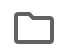 on the left toolbar).  We will use this file as a Python module.  The *lookup.py* file contains a dictionary named GENETIC_CODE.  To check that you have correctly uploaded the *lookup.py* file, run the import statement below.  It should print ('GCT', 'GCC', 'GCA', 'GCG').  Open *lookup.py* and check that you understand why the output of the code block below is ('GCT', 'GCC', 'GCA', 'GCG').

Pause for a moment here.  You have used many Python modules, but now you are learning how to write your own.  Writing your own modules helps keep code uncluttered and re-useable.  This is cool.  Unpause.



In [ ]:
import lookup
print(lookup.GENETIC_CODE['Alanine'])


('GCT', 'GCC', 'GCA', 'GCG')


## AMINO_ACID look up table (ie. dictionary)

The GENETIC_CODE dictionary gives us the list of codons that corresponds to a given amino acid.  Each codon appears only once in the GENETIC_CODE dictionary. We need a dictionary that does the opposite: given a codon, translate it to its corresponding amino acid.  Complete the function `amino_acid_lookup_table()`.  A suggested structure of this algorithm is given in the pseudocode comments below.  You only need to write the function, the assert statements are written for you.

In [ ]:
# amino acid dictionary
def amino_acid_lookup_table():
    '''
        Return a dictionary that maps each Codon onto the Amino Acid it encodes
    '''
    # This function "flips" the GENETIC_CODE dictionary so we can look-up by codon
    # This can be achieved with an accumulator algorithm that iterates through all the
    # entries in the GENETIC_CODE dictionary and accumulates an entry in the AMINO_ACID
    # dictionary each time throught the loop.  This requires a nested loop because there
    # are multiple codons for each amino acid.

    # create an empty dictionary (the one we will return once we fill it)
    codons = {}

    # iterate over the entries in the GENETIC_CODE dictionary
    # you may want to use a 'for key, value in dict.items()' loop (see textbook 12.3)
    for amino_acid, codon_tuple in lookup.GENETIC_CODE.items():

        # iterate over the codon tuple in the codon list
        for codon in codon_tuple:

          # add an entry to the dictionary you created at the start of the algorithm
          # with codon as the key and amino acid as the value
          codons[codon] = amino_acid

    # return the dictionary
    return codons

# create an AMINO_ACID dictionary by calling the amino_acid_lookup_table function
AMINO_ACID = amino_acid_lookup_table()

# Uncomment these unit tests when you are ready to test amino_acid_lookup_table
# if you do it right, these tests will pass
assert len(AMINO_ACID) == 64
assert AMINO_ACID['GCT'] == 'Alanine'

In [ ]:
print(AMINO_ACID)

{'GCT': 'Alanine', 'GCC': 'Alanine', 'GCA': 'Alanine', 'GCG': 'Alanine', 'CGT': 'Arginine', 'CGC': 'Arginine', 'CGA': 'Arginine', 'CGG': 'Arginine', 'AGA': 'Arginine', 'AGG': 'Arginine', 'AAT': 'Asparagine', 'AAC': 'Asparagine', 'GAT': 'Aspartic acid', 'GAC': 'Aspartic acid', 'TGT': 'Cysteine', 'TGC': 'Cysteine', 'CAA': 'Glutamine', 'CAG': 'Glutamine', 'GAA': 'Glutamic acid', 'GAG': 'Glutamic acid', 'GGT': 'Glycine', 'GGC': 'Glycine', 'GGA': 'Glycine', 'GGG': 'Glycine', 'CAT': 'Histidine', 'CAC': 'Histidine', 'ATT': 'Isoleucine', 'ATC': 'Isoleucine', 'ATA': 'Isoleucine', 'TTA': 'Leucine', 'TTG': 'Leucine', 'CTT': 'Leucine', 'CTC': 'Leucine', 'CTA': 'Leucine', 'CTG': 'Leucine', 'AAA': 'Lysine', 'AAG': 'Lysine', 'ATG': 'START', 'TTT': 'Phenylalanine', 'TTC': 'Phenylalanine', 'CCT': 'Proline', 'CCC': 'Proline', 'CCA': 'Proline', 'CCG': 'Proline', 'TCT': 'Serine', 'TCC': 'Serine', 'TCA': 'Serine', 'TCG': 'Serine', 'AGT': 'Serine', 'AGC': 'Serine', 'ACT': 'Threonine', 'ACC': 'Threonine', 'A

## Translate
Write a function to translate a codon sequence into an amino acid sequence.  The input is a list of codons that begin with a START signal and end with a STOP signal (like the output of `translation_seq`) and the return value is a list of the corresponding amino acids - excluding the START and STOP signals.  For example, if the input is `['ATG', 'CCC', 'GCT', 'TAA']` the ouptut would be `['Proline', 'Alanine']`.  If the input list does not start with a START and end with a STOP signal, then return an empty list.
Hint: This is a list “accumulator” algorithm, most easily solved with a full list "traversal by item" thinking.  Remeber that you already have the AMINO_ACID lookup table.


In [ ]:
# Translate
def translate(translation_seq):
  """
    Return a list of amino acids (strings) for the given
    codon translation sequence (list of codons)
    Parameter: translation_seq - list of codons with START and STOP
  """
  aminos = []

  if translation_seq[1] != START and translation_seq[-1] not in STOP:
    return aminos

  for codon in translation_seq[1:-1]:
    aminos.append(AMINO_ACID[codon])

  return aminos

assert translate(['ATG','TAG']) == []
assert translate(['ATG', 'GCT', 'CGT', 'TGA']) == ['Alanine', 'Arginine']
assert translate(['ATG', 'GTG', 'TAC', 'AGC', 'TAA']) == ['Valine', 'Tyrosine', 'Serine']

## Create Output Filename

Write a function that takes a text filename (e.g. `dna.txt`) as a parameter and returns the same filename, but but with the word `-amino-acid` appended (e.g., `dna-amino-acid.txt`).  Note: This is just string processing, you are not dealing with file objects yet. You will need to split the filename at the '.' to create the new filename.  Hint: look up the `split` method for strings.

In [ ]:
def get_output_filename(filename):
  """
    Return output filename with -amino-acid appended
    Parameter: input text filename
  """
  suffix = '-amino-acid'
  base, ext = filename.split('.')
  return base+suffix+'.'+ext

assert (get_output_filename('something.txt')) == 'something-amino-acid.txt'


## Translate File

Write a function that takes a string parameter containing a filename, translates the first protein translation sequence found to an amino acid chain, and writes that chain to an output file.  If the DNA read from the file is not valid, then the function should return `None`. Psuedocode is included to help you write this function.  Test your function with the input file `dna.txt` found on eLearn - note that you will need to copy the file into Colab.  Since this is primarily a side-effect function, you will need to test it manually (ie. no asserts needed).

In [ ]:
def translate_file(filename):
  """
    Reads DNA seq from file and writes amino acids to output file.
    Return output filename
    Parameter: filename - string, file containing DNA sequence
  """
  # open input file for reading
  with open(filename, 'r') as infile:

    # read the input file as a sequence string
    seq = infile.readline()

    # check the sequence is valid
    if not is_valid_seq(seq):
      print('Input sequence is not valid.')
      return None

    # extract the codons from the sequence string
    # (ie. use the extrac_codons function)
    codons = extract_codons(seq)

    # create the translation sequence
    # (ie. use the translation_seq function)
    tran_seq = translation_seq(codons)

    # translate the translation seqenence into amino acids
    # (ie. use the translate function)
    aminos = translate(tran_seq)

  # create an output filename
  # (ie. use the get_output_filename function)
  output_filename = get_output_filename(filename)

  # open the output file for writing
  with open(output_filename, 'w') as outfile:

    # write the amino acid list into the outfile as strings
    outfile.write(str(aminos))

  # return the output filename
  return output_filename

# testing
translate_file('dna.txt')

'dna-amino-acid.txt'

## Main

Write a main function that asks the user to enter the name of an input file containing a DNA sequence (ie. `dna.txt`), creates an output file with the amino acid chain that corresponds to the first protein translation sequence, and tells the user the name of the new file.  

In [ ]:
# main
def main():
  """
    Convert a DNA sequence file to an amino acid chain file.
  """

  # ask user for input filename
  infilename = input('What is the name of your input file? ')

  # translate the file
  outfilename = translate_file(infilename)

  # inform the user of the new output file name
  if outfilename != None:
    print('Your sequence has been translated in the file', outfilename)
  else:
    print('Sorry, your sequence was invalid and could not be translated.')


In [ ]:
main()

What is the name of your input file? dna.txt
Your sequence has been translated in the file dna-amino-acid.txt
